In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data = pd.read_csv("fuzzy_pid_dfso_dataset.csv")
data.head(10)

,Temperature_C,Pressure_Bar,Speed_RPM,Error,Delta_Error,Load_Variation,Ambient_Temp_C,Energy_Consumption_W
0,49.963210,2.666196,1154.264209,1.727030,0.287984,0.957454,27.965139,67.459755
1,96.057145,5.877109,1117.446998,2.966814,1.221729,0.989374,18.447727,134.047638
2,78.559515,8.856513,2765.636451,-2.495321,1.040644,1.141819,32.447891,424.060612
3,67.892679,7.590024,1123.865500,1.248741,-1.384400,0.936002,27.262325,395.045760
4,32.481491,8.259050,1179.874315,0.717460,-1.403002,1.147860,18.144078,207.789211
5,32.479562,6.929050,2398.495656,3.328304,-0.927303,0.835254,34.246761,219.564782
6,24.646689,7.230489,1624.349606,4.060871,-0.555701,1.110719,25.367309,290.099495
7,89.294092,8.642761,2441.776392,-4.878432,-0.366178,1.139019,16.457969,50.108452
8,68.089201,3.247012,663.415394,1.740199,0.718789,0.872727,27.536658,158.559951
9,76.645806,5.404825,1718.927984,-4.481642,-1.773278,0.972139,20.063978,143.704314


In [11]:
data.describe()

,Temperature_C,Pressure_Bar,Speed_RPM,Error,Delta_Error,Load_Variation,Ambient_Temp_C,Energy_Consumption_W
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,59.220524,5.563156,1756.014315,-0.096250,-0.023579,0.999386,24.866177,267.066778
std,23.370989,2.629709,726.685489,2.864893,1.147240,0.115678,5.794673,128.211479
min,20.370562,1.028964,500.029087,-4.993466,-1.999877,0.802474,15.028567,50.108452
25%,38.877861,3.169668,1153.377443,-2.580992,-1.020104,0.899752,19.804433,156.195182
50%,59.744590,5.668605,1751.534799,-0.157207,-0.021608,0.996161,24.692860,267.795814
75%,79.545567,7.844186,2397.758819,2.375408,0.959974,1.095941,30.129287,371.509813
max,99.977414,9.994724,2994.552139,4.995577,1.990998,1.199740,34.989214,499.507115


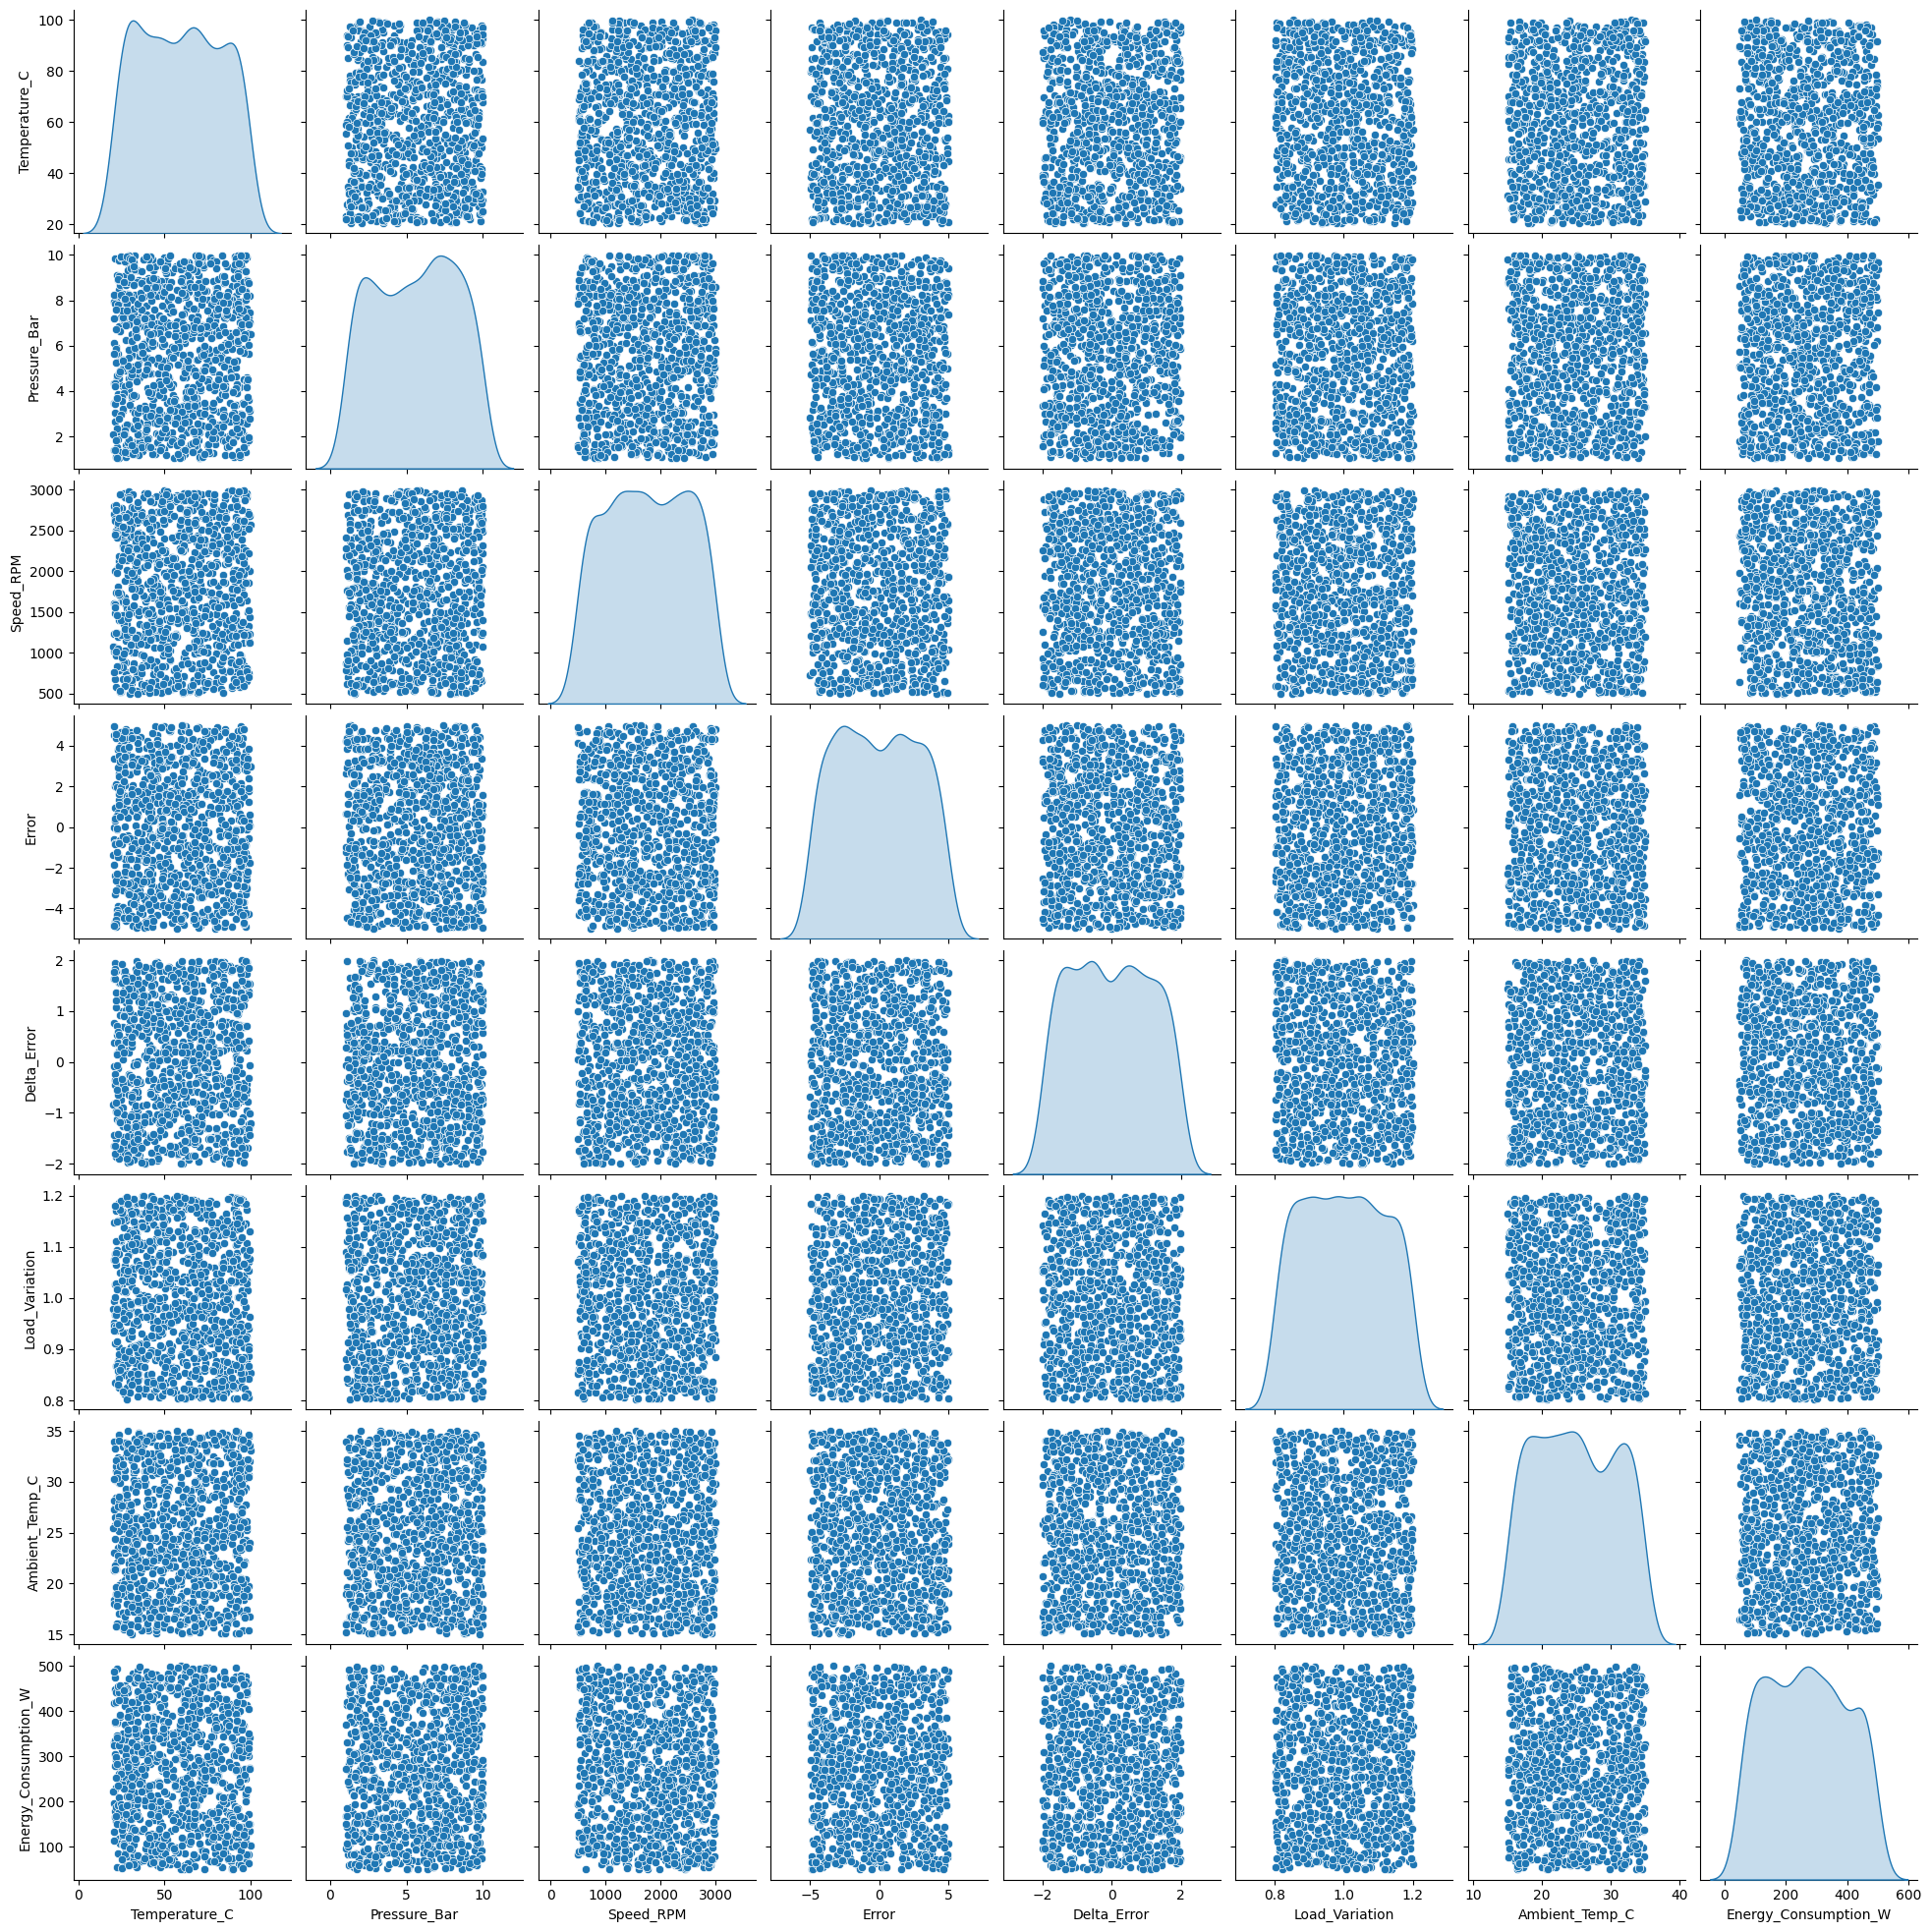

In [15]:
sns.pairplot(data=data, diag_kind='kde')

C:\Users\dangs\AppData\Local\Temp\ipykernel_3604\3698845004.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], cmap='viridis', alpha=0.7, s=50)
C:\Users\dangs\AppData\Local\Temp\ipykernel_3604\3698845004.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
C:\Users\dangs\AppData\Local\Temp\ipykernel_3604\3698845004.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'],
C:\Users\dangs\AppData\Local\Temp\ipykernel_3604\3698845004.py:43: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter3 = ax3.scatter(pca_df['PC1'], pca_df['PC3'],
C:\Users\dangs\AppData\Local\Temp\ipykernel_3604\3698845004.py:50: UserWarning: No data for

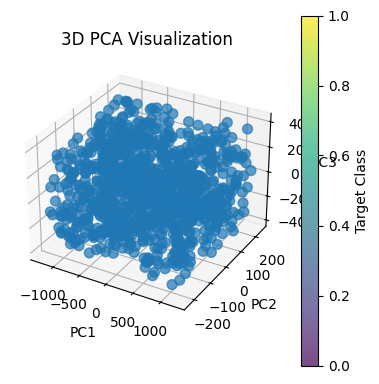

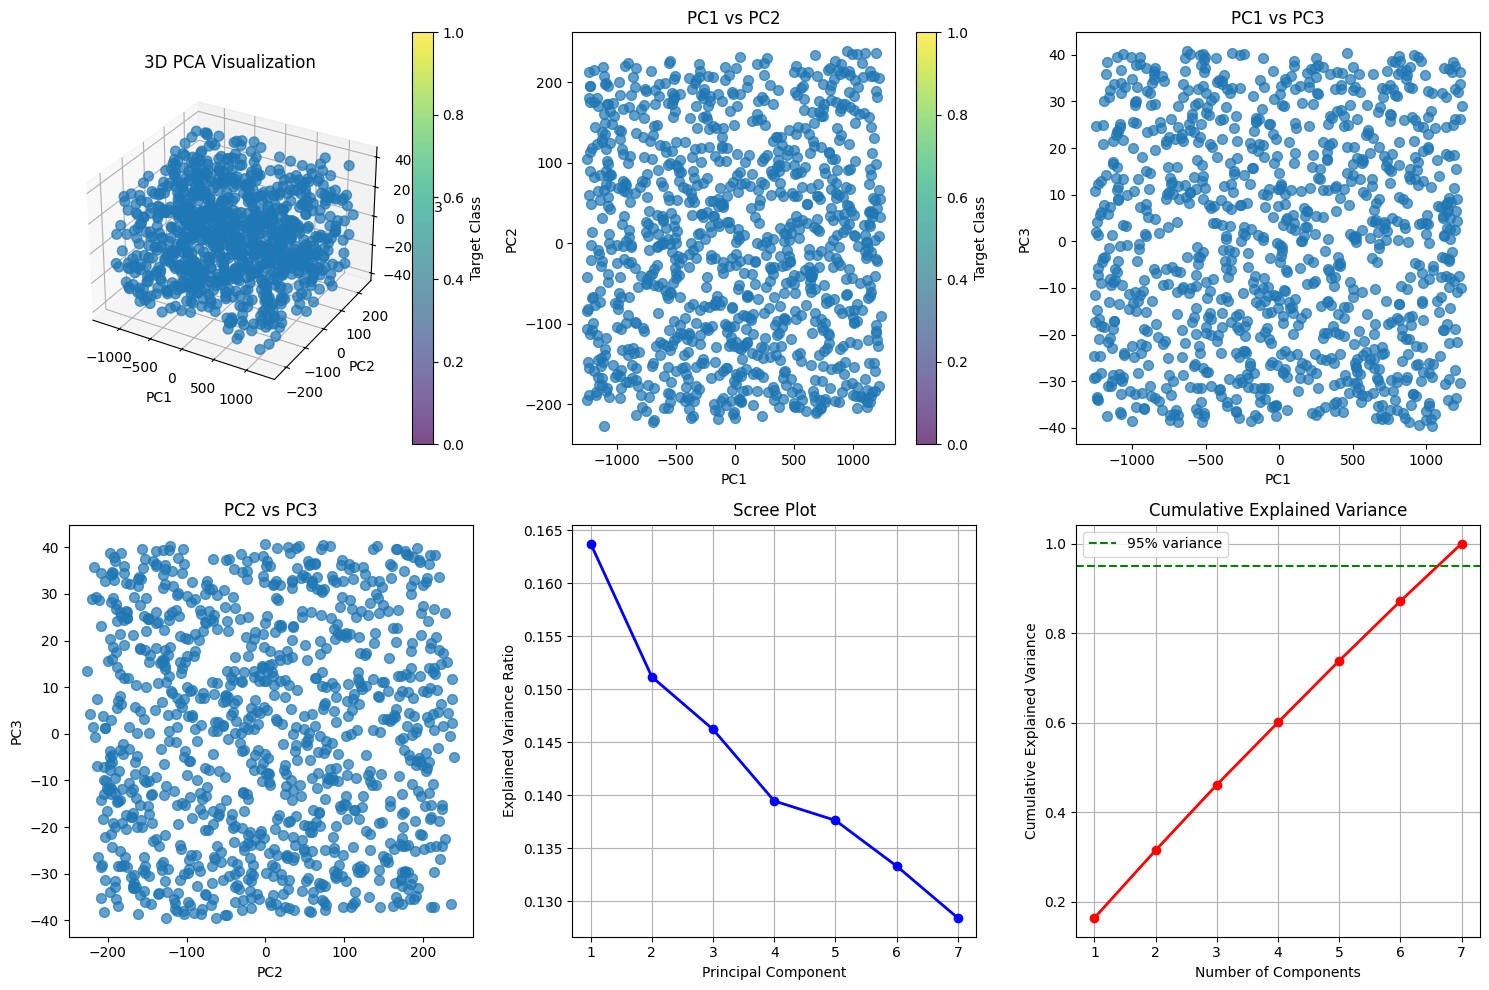

In [14]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
data_pca = pca.fit_transform(data)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2', 'PC3'])

fig = plt.figure(figsize=(15, 10))

# 3D Plot
ax1 = fig.add_subplot(231, projection='3d')
scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], cmap='viridis', alpha=0.7, s=50)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D PCA Visualization')
plt.colorbar(scatter, ax=ax1, label='Target Class')

fig = plt.figure(figsize=(15, 10))

# 3D Plot
ax1 = fig.add_subplot(231, projection='3d')
scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], 
                     cmap='viridis', alpha=0.7, s=50)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D PCA Visualization')
plt.colorbar(scatter, ax=ax1, label='Target Class')

# 2D Projections
ax2 = fig.add_subplot(232)
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], 
                      cmap='viridis', alpha=0.7, s=50)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PC1 vs PC2')
plt.colorbar(scatter2, ax=ax2, label='Target Class')

ax3 = fig.add_subplot(233)
scatter3 = ax3.scatter(pca_df['PC1'], pca_df['PC3'], 
                      cmap='viridis', alpha=0.7, s=50)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC3')
ax3.set_title('PC1 vs PC3')

ax4 = fig.add_subplot(234)
scatter4 = ax4.scatter(pca_df['PC2'], pca_df['PC3'], 
                      cmap='viridis', alpha=0.7, s=50)
ax4.set_xlabel('PC2')
ax4.set_ylabel('PC3')
ax4.set_title('PC2 vs PC3')

# PCA Scree Plot
ax5 = fig.add_subplot(235)
components = range(1, min(10, X.shape[1]) + 1)
pca_full = PCA().fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
ax5.plot(components, explained_variance[:len(components)], 'bo-', linewidth=2)
ax5.set_xlabel('Principal Component')
ax5.set_ylabel('Explained Variance Ratio')
ax5.set_title('Scree Plot')
ax5.grid(True)

# Cumulative Explained Variance
ax6 = fig.add_subplot(236)
cumulative_variance = np.cumsum(explained_variance)
ax6.plot(components, cumulative_variance[:len(components)], 'ro-', linewidth=2)
ax6.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
ax6.set_xlabel('Number of Components')
ax6.set_ylabel('Cumulative Explained Variance')
ax6.set_title('Cumulative Explained Variance')
ax6.legend()
ax6.grid(True)

plt.tight_layout()
plt.show()